# **Case Study: Analyzing Bumble Profiles**


## **Project Background**

Bumble is a popular dating platform where users connect based on mutual interests and compatibility. To provide a better matchmaking experience, Bumble collects user information through profiles, which include details about demographics, lifestyle habits, and personal preferences.

This project analyzes a Bumble dataset to understand user demographics, behavior, and lifestyle patterns. The goal is to clean the data, create relevant features, and explore relationships between variables to identify meaningful trends in user profiles.

## **Importing Libraries and Dataset**

In [1]:
# import libraries and handle import errors
try:
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  import seaborn as sns
  import warnings
  warnings.filterwarnings('ignore')
  print("All libraries imported successfully.")
except ImportError as e:
    print(f"Error importing libraries: {e}")  # Print error if import fails

All libraries imported successfully.


In [2]:
try:
    Bumble_df = pd.read_csv("../dataset/bumble.csv")
    print("Dataset loaded successfully.")
except Exception as e:
  # Print error message if loading fails
    print(f"Failed to load dataset: {e}")

Dataset loaded successfully.


---
---
## **Part 1: Data Cleaning**

### **1. Inspecting Missing Data**

Missing data is a common issue in real-world datasets. On a platform like Bumble, missing user information might reflect gaps in the user profile setup process, incomplete data collection, or users intentionally leaving certain fields blank.

As a data analyst, your role is to:

- Assess the extent of missing data.
- Understand its potential impact.
- Decide the most appropriate methods to address it.

**Q1. Which columns in the dataset have missing values, and what percentage of data is missing in each column?**


In [3]:
# Getting the missing values % for each column
missing_pct = round(Bumble_df.isnull().mean() * 100, 1)

# Filtering out columns with 0 missing values 
missing_pct[missing_pct > 0].sort_values(ascending=False)

diet         40.7
religion     33.7
pets         33.2
sign         18.4
job          13.7
education    11.1
ethnicity     9.5
body_type     8.8
drinks        5.0
speaks        0.1
dtype: float64

**Analysis Approach**
- **isnull()** checks for missing values
- **mean()** calculates the proportion of missing values
- Multiplying by 100 converts the proportion to a percentage
- Multiplying by 100 converts the proportion to a percentage
- missing_percentage[missing_percentage > 0] This keeps only columns that have missing values
- **sort_values(ascending=False)** orders the results from highest to lowest percentage of missing values

---
**Q2. Are there columns where more than 50% of the data is missing? Would you drop those columns where missing values are >50%. If yes, why?**

In [4]:
len(missing_pct[missing_pct > 50])

0

None of the columns have a missing data percentage greater than 50%.

---
**Q3. How would you handle the missing numerical data (e.g., height, income)? Would you impute the missing data by the median or average value of height and income for the corresponding category, such as gender, age group, or location. If yes, why?**

In [5]:
calculate_median = Bumble_df.groupby(["gender"])["height"].transform("median")
Bumble_df["height"] = Bumble_df["height"].fillna(calculate_median)
print(calculate_median)

0        70.0
1        70.0
2        70.0
3        70.0
4        70.0
         ... 
59941    65.0
59942    70.0
59943    70.0
59944    70.0
59945    70.0
Name: height, Length: 59946, dtype: float64


**Analysis Approach**

- Calculate gender-wise median height
- transform("median") This applies the median to each group and returns a Series of the same length as the original, which matches each row with the correct group median.
- Impute missing height values
- The fillna() function fills only the missing values with the computed median for that row’s gender.
- View the computed median values used for imputation

**Result Analysis**

Yes, imputing missing numerical values using the median of a relevant subgroup (like gender, age group, or location) is a statistically sound approach and improves the quality of analysis.


**Why Use Grouped Medians (e.g., by Gender)?**

Different demographic groups have naturally different distributions (e.g., average height differs between males and females). Group-level imputation improves accuracy and preserves natural variability in the data.

---
---
### **2. Data Types**

Accurate data types are critical for meaningful analysis and visualization. For example, numeric fields like income or height must be stored as numbers for statistical computations, while dates like last_online must be converted to datetime format for time-based calculations.

**Q1. Are there any inconsistencies in the data types across columns (e.g., numerical data stored as strings)?**



In [6]:
Bumble_df.dtypes

age              int64
status          object
gender          object
body_type       object
diet            object
drinks          object
education       object
ethnicity       object
height         float64
income           int64
job             object
last_online     object
location        object
pets            object
religion        object
sign            object
speaks          object
dtype: object

Most columns are stored in appropriate data types; numerical fields such as age, height, and income are correctly represented, while last_online is stored as an object and requires conversion.

**Which columns require conversion to numerical data types for proper analysis (e.g., income)?**



None, all numerical columns are already stored in appropriate numeric formats.

**Does the last_online column need to be converted into a datetime format? What additional insights can be gained by analyzing this as a date field?**


In [7]:
Bumble_df['last_online'] = pd.to_datetime(
    Bumble_df['last_online'],
    format='%Y-%m-%d-%H-%M'
)

**Analysis Approach**

- Converting the 'last_online' column to a datetime format using the specified format.
- The format "%Y-%m-%d-%H-%M" expects the date to be in the form 'YYYY-MM-DD-HH-MM'.
- Conversion of last_online column dtype.

**Answer to the Question** The last_online field is given as an object datatype and for further analysis this should be converted into datatime dtype

- Using to_datetime function can convert it into a datetime format.
- format = "%Y-%m-%d-%H-%M" denotes the format of the datetime as Year, month, day, hours and minutes.



---
---
### **3. Outliers**

Outliers are extreme values in the dataset that can distort averages, correlations, and overall trends. In the context of Bumble, an outlier in age (e.g., 110 years old) or income (e.g., $1,000,000 or -1) could represent errors or rare, invalid cases.


**Q1. Are there any apparent outliers in numerical columns such as age, height, or income? What are the ranges of values in these columns?**



In [8]:
Bumble_df[['age', 'height', 'income']].describe()

,age,height,income
count,59946.000000,59946.000000,59946.000000
mean,32.340290,68.295282,20033.222534
std,9.452779,3.994738,97346.192104
min,18.000000,1.000000,-1.000000
25%,26.000000,66.000000,-1.000000
50%,30.000000,68.000000,-1.000000
75%,37.000000,71.000000,-1.000000
max,110.000000,95.000000,1000000.000000


**Outlier Detection in Numerical Columns**

There are apparent outliers present in the numerical columns such as age, height, and income.

To identify potential outliers in the dataset, we performed the following steps:

- Analyzed descriptive statistics for numerical columns using the describe() function in pandas.
- Programmatically calculated the ranges of each column using: (bumble["height"].min(), bumble["height"].max())


**Outlier Observations**

- Age The maximum age value of 110 appears suspiciously high and is likely an outlier, possibly due to a data entry error.

- Height The minimum height value of 1 inch is unrealistic and most likely an error. A value like 95 inches (almost 8 feet) is rare but possible for very tall individuals, though it should still be reviewed.

- Income The placeholder value -1 is clearly invalid and should be treated as missing or non-disclosed. The maximum income value of 1,000,000 is an extreme outlier and could distort average-based analyses.

---

**Q2. Any -1 values in numerical columns like income should be replaced with blank, as they may represent missing or invalid data.**



In [9]:
Bumble_df['income'] = Bumble_df['income'].replace(-1,np.nan)
print(round(Bumble_df['income'].isna().mean()*100,2))

80.81


**Analysis Approach**

Replacing any value of -1 in the 'income' column with nan, using replace(), indicating missing or invalid values Displaying the updated 'income' column


**Handling Invalid or Placeholder Values**

To address invalid or placeholder values in the dataset—particularly -1, which likely represents missing or undisclosed data—each relevant column was cleaned by replacing -1 with nan. This approach ensures that such entries are consistently flagged as invalid or missing.


**Post-Cleaning Validation**

After performing the replacements, a print() check confirmed the updates that multiple records that originally had -1 now show as nan which is 81% of the 'income' column


---
**Q3. For other outliers, how would you ensure that they o not disproportionately impact the analysis while retaining as much meaningful data as possible. Would you delete the data or rather than deleting them, calculate the mean and median values using only the middle 80% of the data (removing extreme high and low values). Provide appropriate reasons for every step.**

In [10]:
def get_filtered_stats(series):
    Q1 = series.quantile(0.10)
    Q3 = series.quantile(0.90)
    filtered_series = series[(series > Q1) & (series < Q3)]
    return filtered_series.mean(), filtered_series.median()

for column in ["income", "age", "height"]:
    mean, median = get_filtered_stats(Bumble_df[column])
    print(f"\n{column}: filtered_median: {median}, filtered_mean: {mean}")


income: filtered_median: 60000.0, filtered_mean: 64559.211439677914

age: filtered_median: 30.0, filtered_mean: 31.357685563997663

height: filtered_median: 68.0, filtered_mean: 68.25442646465552


**Analysis Approach**

Function Overview: get_filtered_stats

The code defines a function called get_filtered_stats that calculates the mean and median of a column after removing outliers (i.e., values outside the 10th and 90th percentiles).

It then loops through selected columns in the bumble DataFrame:

- income
- age
- height

For each column, the function is applied and the filtered mean and median are printed.


**Why This Matters**

- This approach ensures that outliers don't skew the results, while still retaining meaningful data.
- It provides a more robust and representative summary of central tendency for each numerical feature.

---
---
### **4. Missing Data Visualization**

Visualizing missing data helps identify patterns of incompleteness in the dataset, which can guide data cleaning strategies. Understanding which columns have high levels of missing data ensures decisions about imputation or removal are well-informed.

**Q1. Create a heatmap to visualize missing values across the dataset. Which columns show consistent missing data patterns?**


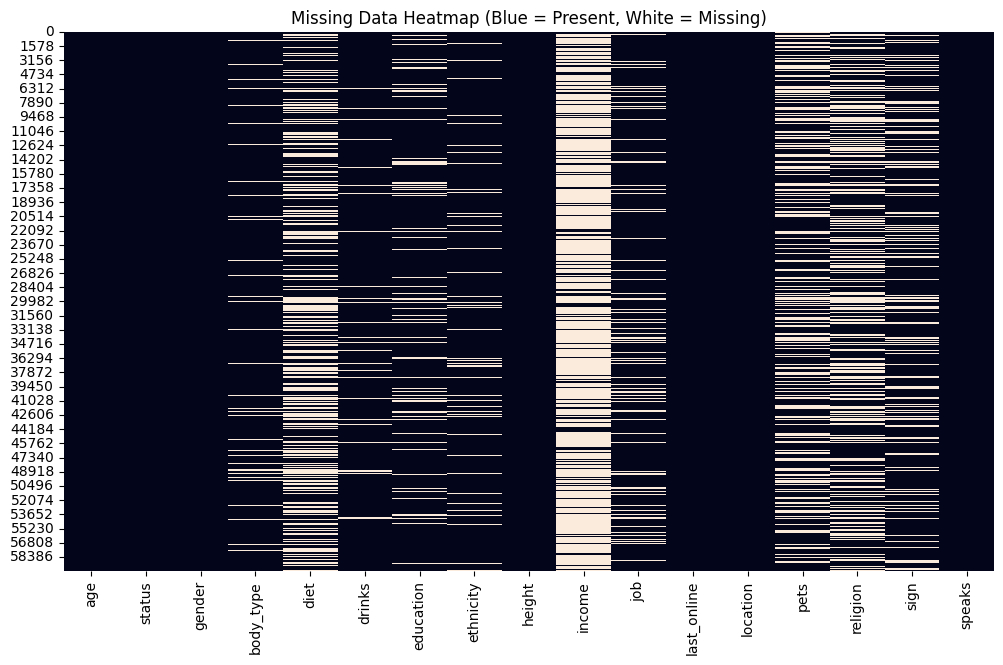

In [11]:
# Set the figure size
plt.figure(figsize=(12, 7))

sns.heatmap(Bumble_df.isnull(), cbar=False)

plt.title('Missing Data Heatmap (Blue = Present, White = Missing)')
plt.show()


The diet, pets and religion column shows consistent data missing patterns

---
---
## **Part 2: Data Processing**

### **1. Binning and Grouping**

Grouping continuous variables, such as **age** or **income**, into bins helps simplify analysis and identify trends among specific groups.

For instance, grouping users into **age ranges** can reveal distinct patterns in behavior or preferences across demographics.

**Q1. How would you bin the age column into categories (e.g. "18-25", "26-35", "36-45", and "46+" ) to create a new column, age_group. How does the distribution of users vary across these age ranges?**


In [12]:
# Define age bins and labels
age_bins = [18, 25, 35, 45, Bumble_df['age'].max()]
age_labels = ['18-25', '26-35', '36-45', '46+']

# Create age group column
Bumble_df['age_group'] = pd.cut(
    Bumble_df['age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# Check age group distribution
age_group_df = (
    Bumble_df['age_group'].value_counts().sort_index().reset_index()
)
age_group_df.columns = ['age_group', 'User Count']
age_group_df

,age_group,User Count
0,18-25,14454
1,26-35,28621
2,36-45,10803
3,46+,6068


**Analysis Approach**

- Counted the number of users in each age group
- Calculated percentage distribution to understand demographic spread

**Insights**

- **26–35:** The largest segment (~47.8%), indicating that the platform is most popular among young adults in this age range.

- **18–25:** Around 24.1% of users fall into this group, showing strong adoption among younger users.

- **36–45:** Approximately 18.0% of users belong to this category, representing a moderate presence of mid-age users.

- **46+:** About 10.1% of users fall into this group, making it the smallest segment.

---
 
**Q2. Group income into categories like "Low Income," "Medium Income," and "High Income" based on meaningful thresholds (e.g., quartiles). What insights can be derived from these groups?**

In [13]:
# Function to categorize based on your specific quartile stats
def categorize_income(x):
    if pd.isna(x): return 'Not Disclosed' # Keep blanks as NaN
    if x <= 20000:
        return 'Low Income'
    elif x <= 100000:
        return 'Medium Income'
    else:
        return 'High Income'

# Apply the categorization
Bumble_df['income_group'] = Bumble_df['income'].apply(categorize_income)

# Check the distribution of those who reported
income_group_df = Bumble_df['income_group'].value_counts().reset_index()

income_group_df.columns = ['income_group', 'User Count']
income_group_df

,income_group,User Count
0,Not Disclosed,48442
1,Medium Income,7203
2,Low Income,2952
3,High Income,1349


**Analysis Approach**

- Counted the number of users in each income group
- Calculated percentage distribution to understand data skew


**Insights**

- **Not Disclosed:** A large majority (~81%) fall into this category, indicating significant missing or undisclosed income data.

- **Medium Income:** Around 12% of users belong to this group, forming the largest segment among users who reported income.

- **Low Income:** Approximately 5% of users fall into this category.

- **High Income:** Only about 2% of users are in this group, showing that high-income users are a small minority in the dataset.

---
---
### **2. Derived and Features**

Derived features are new columns created based on the existing data to add depth to the analysis. These features often reveal hidden patterns or provide new dimensions to explore.

**Q1. Create a new feature, profile_completeness, by calculating the percentage of non-missing values for each user profile. How complete are most user profiles, and how does completeness vary across demographics?**

In [14]:
total_columns = len(Bumble_df.columns)


Bumble_df['profile_completeness'] = (Bumble_df.notnull().sum(axis=1) / total_columns) * 100

print(f"Average Profile Completeness: {Bumble_df['profile_completeness'].mean():.2f}%")

Average Profile Completeness: 86.58%


**Analysis Approach**

Profile completeness was calculated by measuring how many fields in a user's profile are filled versus missing.  
For each user, the number of non-null values across all columns was counted and divided by the total number of columns.  
The result was then multiplied by 100 to express completeness as a percentage.

---

**Creating the `profile_completeness` Feature**

To assess the quality and completeness of user profiles, a new feature called **`profile_completeness`** was created. This feature represents the percentage of profile fields that are filled for each user.

The calculation involved the following steps:

- Determining the **total number of columns** in the dataset.
- Counting the **number of non-null values for each user** across all columns.
- Dividing the number of filled fields by the **total number of fields** to obtain the fraction of completed information.
- Multiplying this value by **100** to convert it into a percentage.

This feature provides a simple metric to evaluate how complete each user profile is and can be useful for analyzing user engagement and profile quality across the platform.

**Output**

The average profile completeness across all users was calculated using the mean of the `profile_completeness` feature.


In [154]:
# Group by gender and look at the average completeness
gender_completeness = round(Bumble_df.groupby('gender')['profile_completeness'].agg(avg_completeness = 'mean'),2)
gender_completeness

,avg_completeness
gender,
f,88.50
m,88.83


**Analysis Approach**

- Calculated the average profile completeness for each gender
- Compared values to identify differences in profile completion behavior

**Insights**

- **Male Users (m):** Average completeness is ~88.83%, slightly higher than female users.

- **Female Users (f):** Average completeness is ~88.50%, very close to male users.

- **Overall:** Profile completeness is consistently high (~88%+) across both genders, indicating minimal variation and similar engagement levels in profile building.

In [155]:
age_group_completeness = round(Bumble_df.groupby('age_group',observed=False).profile_completeness.agg(avg_completeness = 'mean'),2)
age_group_completeness

,avg_completeness
age_group,
18-25,88.69
26-35,88.45
36-45,88.91
46+,89.52


**Analysis Approach**

- Calculated the average profile completeness for each age group
- Compared values to identify variations in engagement across age segments

**Insights**

- **46+:** Highest average completeness (~89.52%), indicating older users tend to create more complete profiles.

- **36–45:** Also relatively high (~88.91%), showing strong profile engagement.

- **18–25:** Around 88.69%, slightly lower but still consistent.

- **26–35:** Lowest among groups (~88.45%), though the difference is minimal.

- **Overall:** Profile completeness is very consistent (~88–89%) across all age groups, suggesting age is not a strong differentiator in profile completion behavior.

In [156]:
status_completeness = round(Bumble_df.groupby('status',observed=False).profile_completeness.agg(avg_completeness = 'mean'),2)
status_completeness

,avg_completeness
status,
available,88.98
married,87.98
seeing someone,88.28
single,88.71


**Analysis Approach**

- Calculated the average profile completeness for each relationship status
- Compared values to identify differences in profile completion behavior

**Insights**

- **Available:** Highest average completeness (~88.98%), indicating slightly higher engagement in profile building.

- **Single:** Around 88.71%, also showing strong profile completeness.

- **Seeing Someone:** Slightly lower at ~88.28%.

- **Married:** Lowest (~87.98%), though the difference is minimal.

- **Overall:** Profile completeness remains consistent (~88%+) across all relationship statuses, suggesting status has little impact on profile completion behavior.

In [157]:
income_group_completeness = round(Bumble_df.groupby('income_group',observed=False).profile_completeness.agg(avg_completeness = 'mean'),2)
income_group_completeness

,avg_completeness
income_group,
High Income,93.71
Low Income,95.01
Medium Income,94.00
Not Disclosed,87.38


**Analysis Approach**

- Calculated the average profile completeness for each income group
- Compared values to identify differences in engagement across income segments


**Insights**

- **Low Income:** Highest average completeness (~95.01%), indicating very strong profile engagement.

- **Medium Income:** Around 94.00%, also showing high completeness.

- **High Income:** Slightly lower at ~93.71%, but still significantly high.

- **Not Disclosed:** Much lower (~87.38%) compared to other groups.

- **Overall:** Users who disclose income tend to have significantly higher profile completeness, while those who do not disclose income show comparatively lower engagement.

---
---


### **3. Unit Conversion**

Standardizing units across datasets is essential for consistency, especially when working with numerical data. In the context of the Bumble dataset, users’ heights are given in inches, which may not be intuitive for all audiences.

**Q1. Convert the height column from inches to centimeters using the conversion factor (1 inch = 2.54 cm). Store the converted values in a new column, height_cm.**


In [22]:
# Conversion factor: 1 inch = 2.54 cm
Bumble_df['height_cm'] = Bumble_df['height'] * 2.54



**Creating the height_cm Feature** To ensure consistency and global interpretability, user height data—originally recorded in inches—was converted to centimeters. The standard conversion factor used was:

**1 inch = 2.54 cm**

A new column, height_cm, was created to store the converted values.

**Sample Output Review**

The transformation is accurate and complete across all 59,946 records, confirming the successful creation of the height_cm feature.

---
---
## **Part 3: Data Analysis**

### **1. Demographic Analysis**

Understanding the demographics of users is essential for tailoring marketing strategies, improving user experience, and designing features that resonate with the platform’s audience. Insights into gender distribution, orientation, and relationship status can help Bumble refine its matchmaking algorithms and engagement campaigns.


**Q1. What is the gender distribution (gender) across the platform? Are there any significant imbalances?**



In [159]:
gender_df = (
    round(Bumble_df['gender'].value_counts(normalize=True)*100, 2)
    .reset_index()
)
gender_df.columns = ['gender', 'Distribution']
gender_df

,gender,Distribution
0,m,59.77
1,f,40.23


**Analyzing Gender Distribution**

The dataset contains a gender column with **59,946** records. The value counts revealed the following distribution:

**Male (m)**: 35,829 users

**Female (f)**: 24,117 users

**Interpretation** There is a significant **gender imbalance** in the dataset:

Males outnumber females by **11,712** users,

This represents approximately a **49% higher male presence** on the platform.

---

**Q2. What are the proportions of users in different status categories (e.g., single, married, seeing someone)? What does this suggest about the platform’s target audience?**

In [15]:
status_df = (
    round(Bumble_df['status'].value_counts(normalize=True)*100, 2)
    .reset_index()
)
status_df.columns = ['status', 'Distribution']
status_df

,status,Distribution
0,single,92.91
1,seeing someone,3.44
2,available,3.11
3,married,0.52
4,unknown,0.02




**Status Proportions** Out of the total users, the proportions for each status category are as follows:

- Single: 92.91%
- Seeing Someone: 3.44%
- Available: 3.11%
- Married: 0.52%
- Unknown: 0.02%


**Interpretation**

- The overwhelming majority (93%) of users identify as single, which aligns well with Bumble’s primary use case:
  - dating
  - finding new connections
- Very few users are married or in a relationship, indicating that the platform’s user base is predominantly comprised of those actively seeking partners.
- The “available” group (3.1%) may suggest openness to dating without specific relationship labels.

---

**Q3. How does status vary by gender? For example, what proportion of men and women identify as single?**

In [161]:
# Group by gender and status, then get counts
gender_status_df = Bumble_df.groupby(['gender', 'status']).size().unstack(fill_value=0)

# Divide each row by its sum to get the percentage WITHIN that gender
gender_dist = gender_status_df.div(gender_status_df.sum(axis=1), axis=0) * 100

# Round for a clean report
round(gender_dist, 2)

status,available,married,seeing someone,single
gender,,,,
f,2.72,0.56,4.16,92.56
m,3.37,0.49,2.96,93.18


**Analysis Approach**

- Grouping the DataFrame by 'status' and 'gender', then calculating the count of each group
- Using size() to count the occurrences and unstack() to reshape the data
- This creates a table where each row is a 'status' and each column is a 'gender'
- fill_value=0 ensures that any missing combinations are filled with 0

**Insights**

- **Single Dominance:** The vast majority of users are single (f: 92.56%, m: 93.18%), indicating the platform is primarily used by individuals actively seeking connections.

- **Available Status:** A slightly higher proportion of male users (3.37%) identify as available compared to female users (2.72%).

- **Seeing Someone:** Female users (4.16%) are more likely than male users (2.96%) to report being in a relationship while still using the platform.

- **Married:** Very small proportion for both genders (f: 0.56%, m: 0.49%), showing minimal presence of married users.

- **Overall:** Gender differences exist but are relatively minor, with both groups heavily concentrated in the “single” category.

---
---


### **2. Correlation Analysis**

Correlation analysis helps uncover relationships between variables, guiding feature engineering and hypothesis generation. For example, understanding how age correlates with income or word count in profiles can reveal behavioral trends that inform platform design.


**Q1. What are the correlations between numerical columns such as age, income, gender Are there any strong positive or negative relationships?**


In [16]:
# 1. Map gender to numbers (0 and 1)
# This allows us to include it in a correlation matrix
Bumble_df['gender_numeric'] = Bumble_df['gender'].map({'f': 0, 'm': 1})

# 2. Select only the numeric columns
# We use 'income' even with NaNs because Pandas .corr() ignores NaNs automatically
numeric_cols = Bumble_df[['age', 'income', 'gender_numeric', 'height']]

# 3. Create the correlation matrix
corr_matrix = numeric_cols.corr()

corr_matrix

,age,income,gender_numeric,height
age,1.000000,-0.009234,-0.041481,-0.022253
income,-0.009234,1.000000,0.053709,0.058829
gender_numeric,-0.041481,0.053709,1.000000,0.655455
height,-0.022253,0.058829,0.655455,1.000000



**Correlations Between Numerical Columns** There are no strong correlations among the numerical variables.

- **Age vs. Income**: Very weak negative correlation (-0.001) — essentially no relationship.

- **Height vs. Income**: Slight positive correlation (0.065) — weak and likely not meaningful.

- **Age vs. Height**: Slight negative correlation (-0.022) — again, not significant.

---

**Q2. How does age correlate with income? Are older users more likely to report higher income levels?**


In [17]:
correlation_with_A = Bumble_df['age'].corr(Bumble_df['income'])
print(correlation_with_A)

-0.009234456267984208


The printed value (-0.0010038...) confirms a **negligible negative correlation** between age and income.

**Conclusion**: Older users are **not significantly more or less likely** to report higher income levels.

---
---
### **3. Diet and Lifestyle Analysis**

Lifestyle attributes such as diet, drinks provide insights into user habits and preferences. Analyzing these factors helps identify compatibility trends and inform product features like filters or match recommendations.

**Q1. How do dietary preferences (diet) distribute across the platform? For example, what percentage of users identify as vegetarian, vegan, or follow "anything" diets?**



In [163]:
# 1. Create a simplified mapping
diet_map = {
    'mostly anything': 'Anything', 'anything': 'Anything', 'strictly anything': 'Anything',
    'mostly vegetarian': 'Vegetarian', 'strictly vegetarian': 'Vegetarian', 'vegetarian': 'Vegetarian',
    'mostly vegan': 'Vegan', 'strictly vegan': 'Vegan', 'vegan': 'Vegan',
    'mostly other': 'Other', 'strictly other': 'Other', 'other': 'Other',
    'mostly kosher': 'Other', 'strictly kosher': 'Other', 'kosher': 'Other',
    'mostly halal': 'Other', 'strictly halal': 'Other', 'halal': 'Other'
}

# 2. Apply mapping and calculate based ONLY on people who answered
Bumble_df['diet_cleaned'] = Bumble_df['diet'].map(diet_map)

# Use value_counts(normalize=True) to get percentages of the VALID responses (ignoring NaNs)
diet_dist = (Bumble_df.diet_cleaned.value_counts(normalize=True) * 100).round(2).reset_index()
diet_dist.columns = ['Diet Group', 'Distribution']

diet_dist

,Diet Group,Distribution
0,Anything,78.43
1,Vegetarian,14.03
2,Other,5.57
3,Vegan,1.97


**Analysis Approach**

- Calculated the percentage distribution of users across diet groups
- Compared proportions to understand dominant lifestyle preferences

**Insights**

- **Anything:** The majority of users (~78.43%) fall into this category, indicating most users do not follow strict dietary restrictions.

- **Vegetarian:** Around 14.03% of users identify as vegetarian, forming the largest specific dietary group.

- **Other:** Approximately 5.57% fall into miscellaneous or less common diet categories.

- **Vegan:** A small minority (~1.97%) follow a vegan diet.

- **Overall:** The user base is largely flexible in dietary habits, with only a small proportion adhering to strict diets like vegetarian or vegan.

---

**Q2. How do drinking habits (drinks) vary across different diet categories? Are users with stricter diets (e.g., vegan) less likely to drink?**

In [164]:
diet_drinks_df = Bumble_df.groupby(['diet_cleaned', 'drinks']).size().unstack(fill_value=0)

diet_dist = diet_drinks_df.div(diet_drinks_df.sum(axis=1), axis=0) * 100

round(diet_dist, 2)

drinks,desperately,not at all,often,rarely,socially,very often
diet_cleaned,,,,,,
Anything,0.56,4.85,9.72,8.69,75.28,0.90
Other,1.79,11.88,6.15,17.35,61.25,1.58
Vegan,1.80,18.11,8.98,17.37,52.69,1.05
Vegetarian,0.71,6.62,7.80,13.65,70.47,0.75


**Analysis Approach**

- Analyzed the distribution of drinking habits across different diet groups
- Compared percentage patterns to identify lifestyle correlations between diet and alcohol consumption

**Insights**

- **Social Drinking Dominates:** Across all diet groups, “socially” is the most common drinking behavior (Anything: 75.28%, Vegetarian: 70.47%, Other: 61.25%, Vegan: 52.69%).

- **Non-Drinkers Trend:** Vegan (18.11%) and “Other” (11.88%) diet groups have a higher proportion of users who do not drink at all compared to “Anything” (4.85%) and Vegetarian (6.62%).

- **Frequent Drinking:** Users in the “Anything” group show higher participation in frequent drinking categories (often, very often, desperately) compared to other diet groups.

- **Moderate Drinking:** Vegetarian and Vegan users lean more toward moderate patterns (“rarely” and “socially”) rather than frequent drinking.

- **Overall:** Users with more restrictive diets (Vegan, Vegetarian) tend to have more conservative drinking habits, while users with flexible diets (“Anything”) are more likely to engage in frequent alcohol consumption.

---
---
### **4. Geographical Insights**

Analyzing geographical data helps Bumble understand its user base distribution, enabling targeted regional campaigns and feature localization. For instance, identifying the top cities with active users can guide marketing efforts in those areas.

**Q1. Extract city and state information from the location column. What are the top 5 cities and states with the highest number of users?**


In [19]:
Bumble_df[['city', 'state']] = Bumble_df.location.str.split(", ",n=1,expand=True)


In [20]:
top_5_cities = Bumble_df['city'].value_counts(ascending=False).head(5)

print("TOP 5 CITIES WITH HIGHEST NUMBER OF USERS:", top_5_cities)

top_5_states = Bumble_df['state'].value_counts(ascending=False).head(5)

print("TOP 5 STATES WITH HIGHEST NUMBER OF USERS:", top_5_states)

TOP 5 CITIES WITH HIGHEST NUMBER OF USERS: city
san francisco    31064
oakland           7214
berkeley          4212
san mateo         1331
palo alto         1064
Name: count, dtype: int64
TOP 5 STATES WITH HIGHEST NUMBER OF USERS: state
california       59855
new york            17
illinois             8
massachusetts        5
texas                4
Name: count, dtype: int64


**Analysis Approach**

- Counting the number of occurrences for each unique city in the 'city' column
- value_counts(ascending=False) sorts the cities in descending order based on the count
- head(5) returns the top 5 cities with the highest number of users
- Displaying the top 5 cities with the highest number of users
- Counting the number of occurrences for each unique state in the 'state' column
- value_counts(ascending=False) sorts the states in descending order based on the count
- head(5) returns the top 5 states with the highest number of users

---
**Q2. How does age vary across the top cities? Are certain cities dominated by younger or older users?**

In [168]:
# 2. Filter the dataframe to only include these cities
top_cities_data = Bumble_df[Bumble_df['city'].isin(top_5_cities['City'])]

city_age_count = top_cities_data.groupby(['city', 'age_group'],observed=False).size().unstack(fill_value=0)

city_age_dist = city_age_count.div(city_age_count.sum(axis=1), axis=0) * 100

round(city_age_dist, 2)

age_group,18-25,26-35,36-45,46+
city,,,,
berkeley,33.62,42.26,13.03,11.09
oakland,19.64,48.53,21.36,10.47
palo alto,28.29,45.96,13.44,12.31
san francisco,22.21,52.83,18.47,6.49
san mateo,21.86,45.68,18.63,13.82


**Analysis Approach**

- Getting the names of the top 5 cities with the highest number of users
- value_counts() counts the number of occurrences for each city
- head(5) returns the top 5 cities, and index.tolist() extracts the city names into a list
- Filtering the DataFrame to include only users from the top 5 cities
- Grouping the filtered DataFrame by 'city' and 'age_group', and counting the number of users in each group
- size() counts the number of occurrences, and unstack() reshapes the data to have 'age_group' as columns
- fillna(0) fills any missing values with 0 (for cities/age_groups with no users)

**Insights**

- San Francisco has by far the highest number of users, especially in the 26–35 and 36–45 age groups.
- Oakland and Berkeley have strong 18–35 populations but fewer users in older brackets.
- Palo Alto and San Mateo show smaller user bases but follow a similar trend, with more users under 36.



**Answer to the Question**

Yes, younger users (especially 26–35) dominate in most top cities. This suggests the platform skews toward a younger demographic, particularly in tech-heavy urban areas like San Francisco and Oakland.

---

**Q3. What are the average income levels in the top states or cities? Are there regional patterns in reported income?**



In [182]:
# 4. Calculate Average Income for Top 5 States
state_income = (
    Bumble_df[Bumble_df['state'].isin(top_5_states['State'])]
    .groupby('state')['income']
    .agg(avg_income = 'mean')
    .sort_values('avg_income',ascending=False)
    .reset_index()
    .round(0)
    .fillna(0)
)
state_income

,state,avg_income
0,new york,270000.0
1,california,104426.0
2,massachusetts,30000.0
3,texas,20000.0
4,illinois,0.0


**Insights**

- **New York and California** have significantly higher reported incomes compared to other states in the sample, indicating **higher earning potential** or cost of living in these regions.
- **Massachusetts and Texas** show considerably **lower average incomes** in this dataset.
- **Illinois** reports an average income of zero, suggesting either missing or unreported data that wasn't properly filtered during preprocessing.



**Regional Patterns**

- Coastal states like **New York** and **California** typically have higher incomes, aligning with national economic trends.

- States with **low average incomes** may suffer from incomplete or poor-quality data, which should be addressed through better **preprocessing** (e.g., removing or imputing 0 income values).

--- 
---

### **5. Height Analysis**

Physical attributes like height are often considered important in dating preferences. Analyzing height patterns helps Bumble understand user demographics and preferences better.

**Q1. What is the average height of users across different gender categories?**

In [23]:
# Group by gender and calculate the average of your new height_cm column
gender_height = (
    Bumble_df.groupby('gender')['height_cm']
    .mean()
    .round(1) # Round to one decimal place for a clean report
    .reset_index()
)
gender_height

,gender,height_cm
0,f,165.4
1,m,178.9



**Analysis Approach**

**mean()** calculates the mean height for each group (gender) in the DataFrame


**Insight**

On average, **male** users are approximately **5.34 inches taller** than **female** users.

---

**Q2. How does height vary by age_group? Are there noticeable trends among younger vs. older users?**


In [172]:
# Group by your age_group column and calculate the average height
age_height_trend = (
    Bumble_df.groupby('age_group', observed=False)['height_cm']
    .mean()
    .round(1)
    .reset_index()
)
age_height_trend

,age_group,height_cm
0,18-25,173.2
1,26-35,173.8
2,36-45,173.6
3,46+,172.6




**Analysis Approach**

- Grouping the DataFrame by 'age_group' and calculating the average height for each age group
- **mean()** calculates the mean height for each group (age_group) in the DataFrame


**Insight**

- Height remains fairly consistent across age groups, with only minor variation.
- A slight peak is seen in the 36–45 age group.
- A very small decline appears in the 46+ group, possibly reflecting posture or generational differences.

---

**Q3. What is the distribution of height within body_type categories (e.g., athletic, curvy, thin)? Do the distributions align with expectations?**


In [25]:
# 1. Define the bins and labels for height
# Using 100 and 250 as extreme boundaries to catch everyone
height_bins = [0, 165, 180, 250]
height_labels = ['Short (<165cm)', 'Average (165-180cm)', 'Tall (>180cm)']

# 2. Create the height_group column
Bumble_df['height_group'] = pd.cut(Bumble_df['height_cm'], bins=height_bins, labels=height_labels)

# 3. Group by body_type_clean and height_group
# We use observed=False to keep all categories in the table
body_height_dist = Bumble_df.groupby(['body_type', 'height_group'], observed=False).size().unstack(fill_value=0)

# 4. Convert to percentages within each body type
body_height_pct = body_height_dist.div(body_height_dist.sum(axis=1), axis=0) * 100

round(body_height_pct, 2)

height_group,Short (<165cm),Average (165-180cm),Tall (>180cm)
body_type,,,
a little extra,15.63,48.38,35.98
athletic,7.86,49.21,42.93
average,19.08,52.88,28.04
curvy,42.46,53.19,4.36
fit,15.99,52.14,31.88
full figured,30.13,59.27,10.60
jacked,16.63,43.71,39.67
overweight,15.32,49.32,35.36
rather not say,31.31,43.43,25.25


**Analysis Approach**

- Analyzed the distribution of height groups across different body types
- Compared percentage patterns to understand how physical attributes are distributed


**Insights**

- **Average Height Dominance:** The majority of users across all body types fall within the average height range (165–180 cm), typically around 45–60%.

- **Tall Users:** Higher proportions of tall users (>180 cm) are observed in body types like **athletic (42.93%)**, **jacked (39.67%)**, and **used up (37.46%)**, suggesting a tendency for taller individuals to associate with more muscular or fit body types.

- **Short Users:** Body types such as **curvy (42.46%)** and **full figured (30.13%)** have a higher proportion of shorter users (<165 cm).

- **Balanced Distributions:** Categories like **average**, **fit**, and **thin** show a more balanced spread but still lean heavily toward average height.

- **Low Tall Representation:** Body types like **curvy (4.36%)** and **full figured (10.60%)** have very low representation in the tall category.

- **Overall:** While average height dominates across all body types, taller individuals are more commonly associated with athletic or muscular body types, whereas shorter heights are more prevalent in curvier categories.

---
---

### **6. Income Analysis**

Income is often an important factor for users on dating platforms. Understanding its distribution and relationship with other variables helps refine features like user search filters or personalized recommendations.

**Q1. What is the distribution of income across the platform? Are there specific income brackets that dominate? How would you handle case where income is blank or 0?**


In [174]:
# 3. Calculate the distribution (including NaNs)
income_dist = Bumble_df['income_group'].value_counts(dropna=False, normalize=True) * 100
round(income_dist, 2).reset_index() 

,income_group,proportion
0,Not Disclosed,80.81
1,Medium Income,12.02
2,Low Income,4.92
3,High Income,2.25


---
**Q2. How does income vary by age_group and gender? Are older users more likely to report higher incomes?**

In [178]:
# Filter out the 'Not Disclosed' or 0 values so they don't drag down the average
reported_income = Bumble_df[Bumble_df['income'] > 0]

# Group by Age Group and Gender
age_gender_income = (
    reported_income.groupby(['age_group', 'gender'], observed=False)['income']
    .median()
    .unstack()
    .round(0)
)
age_gender_income

gender,f,m
age_group,,
18-25,20000.0,30000.0
26-35,40000.0,60000.0
36-45,60000.0,80000.0
46+,60000.0,80000.0


**Analysis Approach**

- Filtered out users with missing or undisclosed income (income ≤ 0)
- Calculated the median income for each age group and gender
- Used median instead of mean to reduce the impact of extreme values


**Insights**

- **Income Increases with Age:** Median income rises consistently with age for both genders, peaking in the 36–45 and 46+ groups.

- **Gender Gap:** Across all age groups, male users report higher median income than female users.

- **Early Career Gap:** The gap starts early (18–25: 20k vs 30k) and widens in mid-career stages (26–35: 40k vs 60k).

- **Income Plateau:** Income growth stabilizes after 36, with both 36–45 and 46+ groups showing similar median values.

- **Overall:** Age is a strong predictor of income progression, while a consistent gender income gap exists across all age groups.

---
---

## **Part 4: Data Visualization**
### **1. Age Distribution**

Understanding the distribution of user ages can reveal whether the platform caters to specific demographics or age groups. This insight is essential for targeted marketing and user experience design.


**Q1. Plot a histogram of age with a vertical line indicating the mean age. What does the distribution reveal about the most common age group on the platform?**


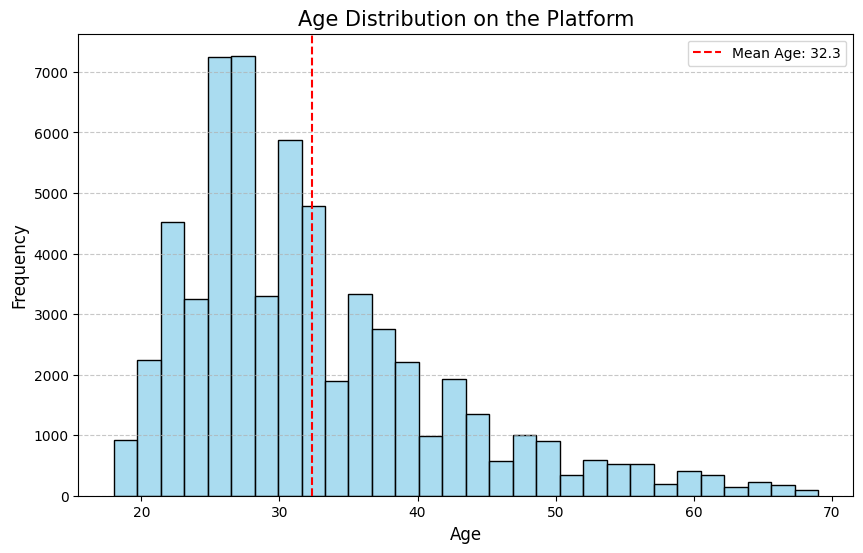

In [185]:
# Calculate mean
mean_age = Bumble_df['age'].mean()

plt.figure(figsize=(10, 6))
# Create the histogram
sns.histplot(Bumble_df['age'], bins=30, color='skyblue', alpha=0.7)

# Add the vertical line for the mean
plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean Age: {mean_age:.1f}')

plt.title('Age Distribution on the Platform', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



**Chart Result Analysis**

- The distribution is right-skewed, indicating that most users are younger.

- The highest concentration of users is between the ages of 18 and 30.

- The mean age (shown by the red dashed line) is around 30 years, but due to the skewness, most users are younger than the mean.

- A small number of users are above 50, and very few are above 60, indicating that the platform is primarily popular among younger adults.

---

**Q2. How does the age distribution differ by gender? Are there age groups where one gender is more prevalent?**


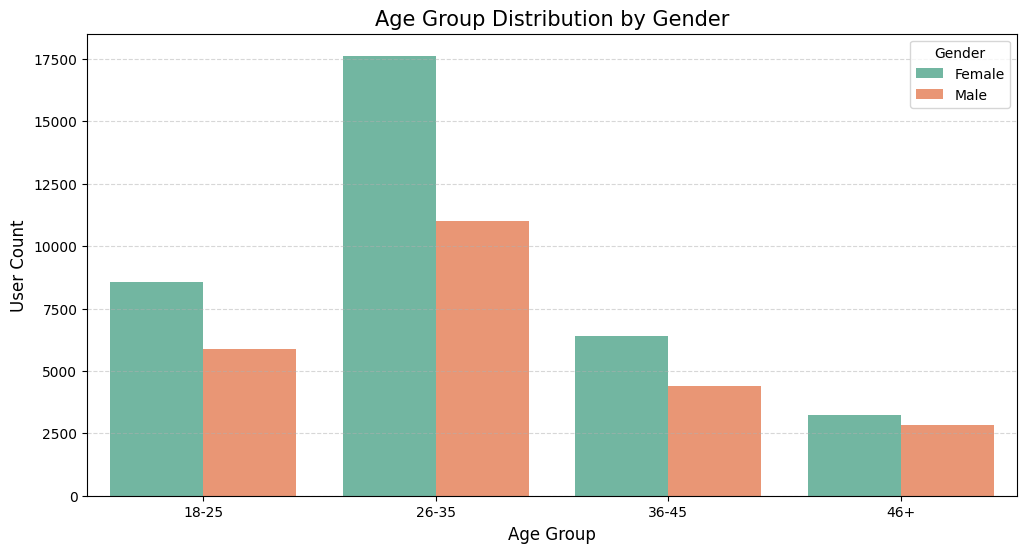

In [187]:
plt.figure(figsize=(12, 6))

# Plotting the count of users per age group, split by gender
sns.countplot(data=Bumble_df, x='age_group', hue='gender', palette='Set2')

plt.title('Age Group Distribution by Gender', fontsize=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('User Count', fontsize=12)
plt.legend(title='Gender', labels=['Female', 'Male']) # Assumes 'f' and 'm' mapping
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Chart Result Analysis**

Yes, there are age groups where one gender is more prevalent:

- In the 18-25 age group, males are significantly more prevalent than females.

- In the 26-35 age group, males are still more prevalent, but the gap narrows slightly.

- The 36-45 age group shows a more balanced distribution, but males are still slightly more than females.

- The 46+ age group is almost balanced between males and females.

Overall, males are more prevalent in the younger age groups (18-35), while the gender distribution becomes more balanced in older age groups.

---
---


### **2. Income and Age**

Visualizing the relationship between income and age helps uncover patterns in reported income levels across age groups, which could inform user segmentation strategies.

**Q1. Use a scatterplot to visualize the relationship between income and age, with a trend line indicating overall patterns. Are older users more likely to report higher incomes?**


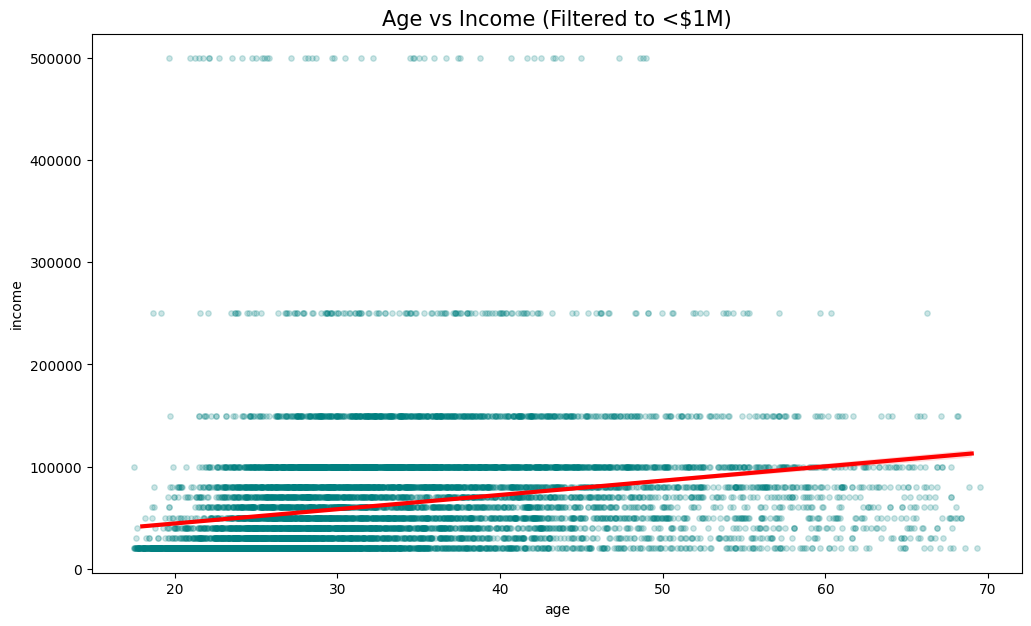

In [202]:
plt.figure(figsize=(12, 7))

# 1. We use 'x_jitter' to spread the dots out so we can see density
# 2. We filter out the 1,000,000 outliers which are likely "trolls" or "flexing"
filtered_df = Bumble_df[(Bumble_df['income'] > 0) & (Bumble_df['income'] < 1000000)]

sns.regplot(data=filtered_df, x='age', y='income', 
            x_jitter=0.5, # Adds a little horizontal "shake"
            scatter_kws={'alpha':0.2, 'color':'teal', 's':15}, 
            line_kws={'color':'red', 'lw':3})

plt.title('Age vs Income (Filtered to <$1M)', fontsize=15)
plt.show()


**Chart Result Analysis**

- The red trendline is almost flat, indicating no strong relationship between age and income.

- While there are a few high-income outliers in various age groups, most users, regardless of age, report lower incomes.

- Older users are not significantly more likely to report higher incomes than younger users.

- The lack of a clear upward slope suggests that income does not consistently increase with age among the users in this dataset.

---

**Q2. Create boxplots of income grouped by age_group. Which age group reports the highest median income?**


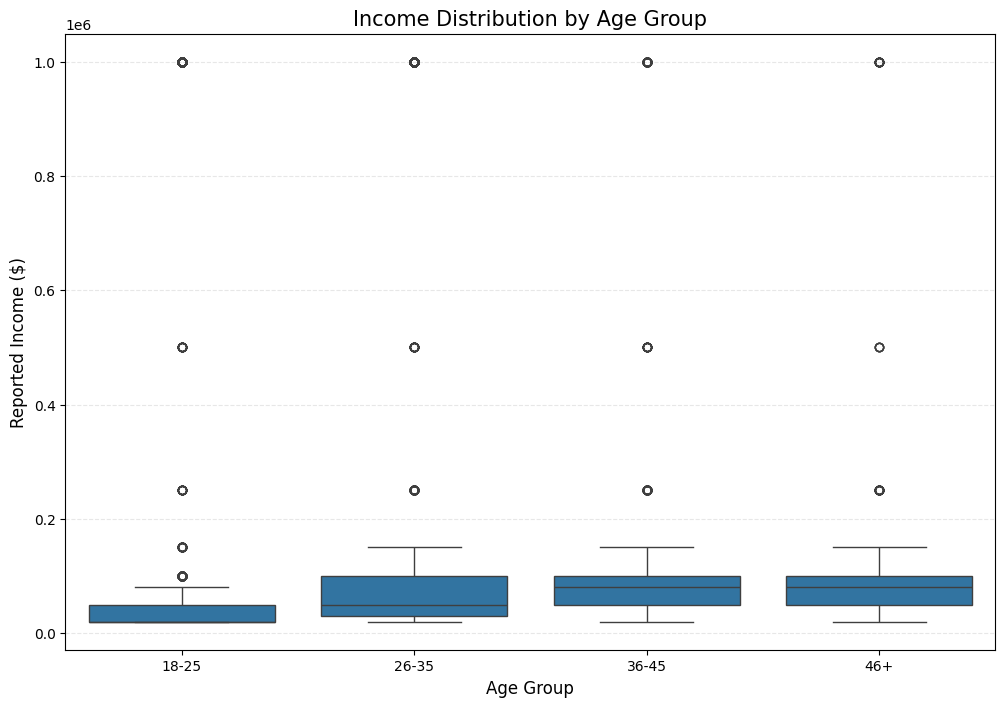

In [24]:
plt.figure(figsize=(12, 8))

# Create boxplot grouped by age_group
sns.boxplot(data=Bumble_df[Bumble_df['income'] > 0], 
            x = 'age_group', 
            y='income', 
   )

plt.title('Income Distribution by Age Group', fontsize=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Reported Income ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

**Chart Result Analysis**

- The 26-35 age group reports the highest median income, with a median value significantly above the other groups.

- The 46+ age group has the second highest median income, but it is slightly lower than the 26-35 group.

- The 36-45 age group has a lower median income compared to the 26-35 and 46+ groups.

- The 18-25 age group has the lowest median income, with a much smaller interquartile range, indicating less variation in income within this group.

- Overall, the 26-35 age group stands out as having the highest earnings, likely reflecting a period of peak earning potential for many individuals.

----

**Q3. Analyze income levels within gender and status categories. For example, are single men more likely to report higher incomes than single women?**


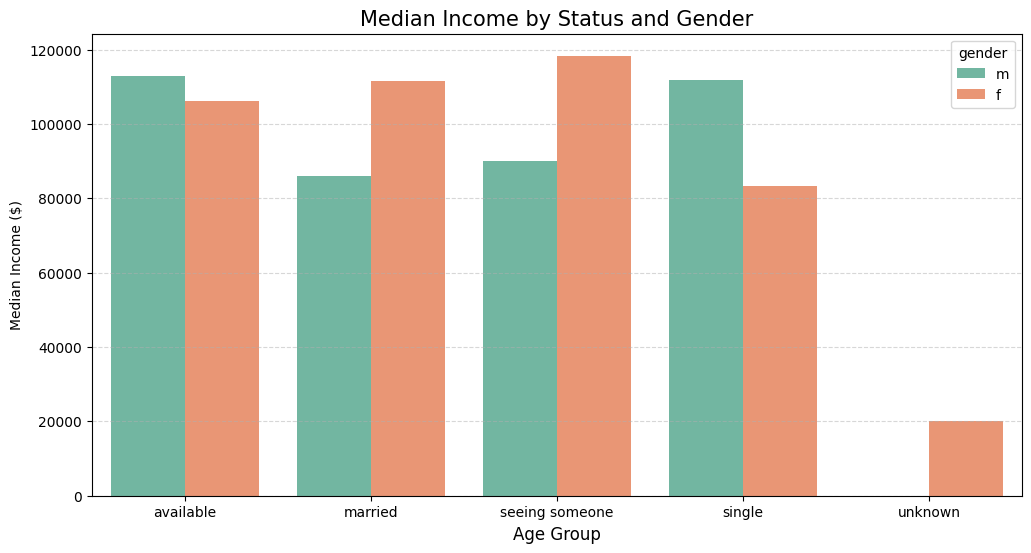

In [29]:
gender_status_income = Bumble_df.groupby(['gender','status'],as_index = False).income.agg(med_income='mean').sort_values('gender',ascending = False)

plt.figure(figsize=(12, 6))

sns.barplot(data=gender_status_income, x='status', y='med_income', hue='gender', palette='Set2')

plt.title('Median Income by Status and Gender', fontsize=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Income ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Chart Result Analysis**

- Single men report higher incomes on average compared to single women.

- For the available status, men have higher average incomes than women, and their income range is more spread out (higher variation).

- Among those seeing someone, the income levels between men and women are more balanced, but men still have slightly higher incomes.

- Married men report higher incomes than married women, with a wide range of income variation among married men.

- For the unknown relationship status, the income for women appears slightly higher, but this group has the lowest average income overall.

- In general, men tend to report higher incomes than women across all relationship status categories.

---
---

### **3. Pets and Preferences**

Pets are often a key lifestyle preference and compatibility factor. Analyzing how pets preferences distribute across demographics can provide insights for filters or recommendations.

**Q1. Create a bar chart showing the distribution of pets categories (e.g., likes dogs, likes cats). Which preferences are most common?**


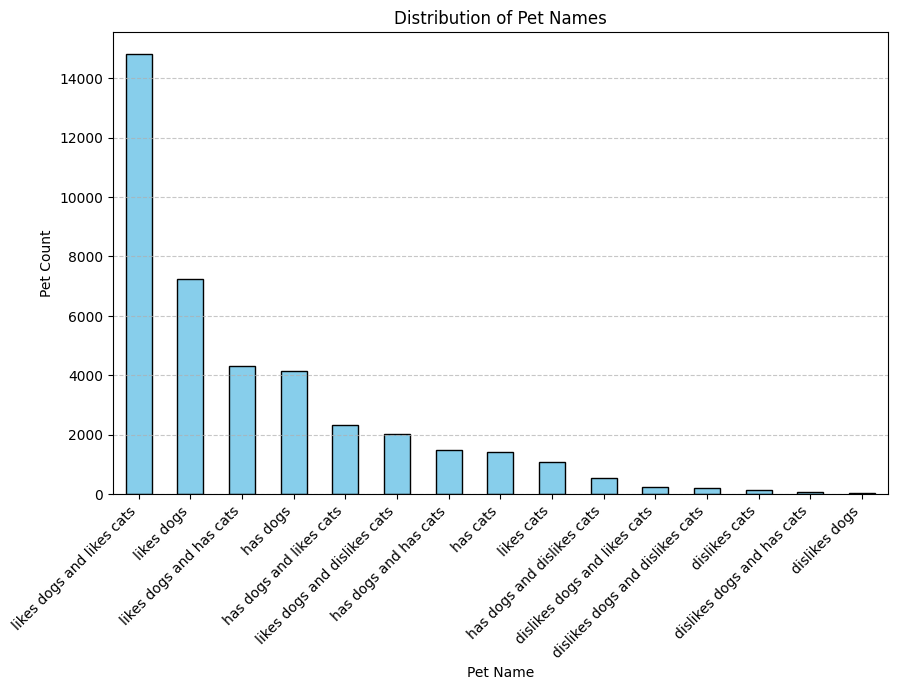

In [31]:
# Count each pet name
Bumble_df["pets"].value_counts().plot(kind="bar", figsize=(10, 6), color='skyblue', edgecolor='black')

plt.xlabel("Pet Name")
plt.ylabel("Pet Count")
plt.title("Distribution of Pet Names")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)



**Chart Result Analysis**

- The most common preference is likes dogs and likes cats, with a significantly higher count than any other category.

- Likes dogs is the second most common preference.

- Has dogs and has cats and has dogs are also popular categories.

- Preferences involving disliking either dogs or cats are the least common, suggesting that most users are generally pet-friendly.

- Users who dislike pets (either dogs or cats) represent a minimal portion of the population.

- This distribution suggests a strong preference for users who are open to both dogs and cats.

---

**Q2. How do pets preferences vary across gender and age_group? Are younger users more likely to report liking pets compared to older users?**


In [275]:
# Define the map
pet_map = {
    # Likes/Has at least one
    'likes dogs and likes cats': 'Likes Pets',
    'has cats': 'Likes Pets',
    'likes cats': 'Likes Pets',
    'has dogs and likes cats': 'Likes Pets',
    'likes dogs and has cats': 'Likes Pets',
    'likes dogs and dislikes cats': 'Likes Pets',
    'has dogs': 'Likes Pets',
    'has dogs and dislikes cats': 'Likes Pets',
    'likes dogs': 'Likes Pets',
    'has dogs and has cats': 'Likes Pets',
    'dislikes dogs and has cats': 'Likes Pets',
    'dislikes dogs and likes cats': 'Likes Pets',
    
    # Only mentions dislikes
    'dislikes dogs and dislikes cats': 'Dislikes Pets',
    'dislikes cats': 'Dislikes Pets',
    'dislikes dogs': 'Dislikes Pets'
}

Bumble_df['pet_sentiment'] = Bumble_df['pets'].map(pet_map)

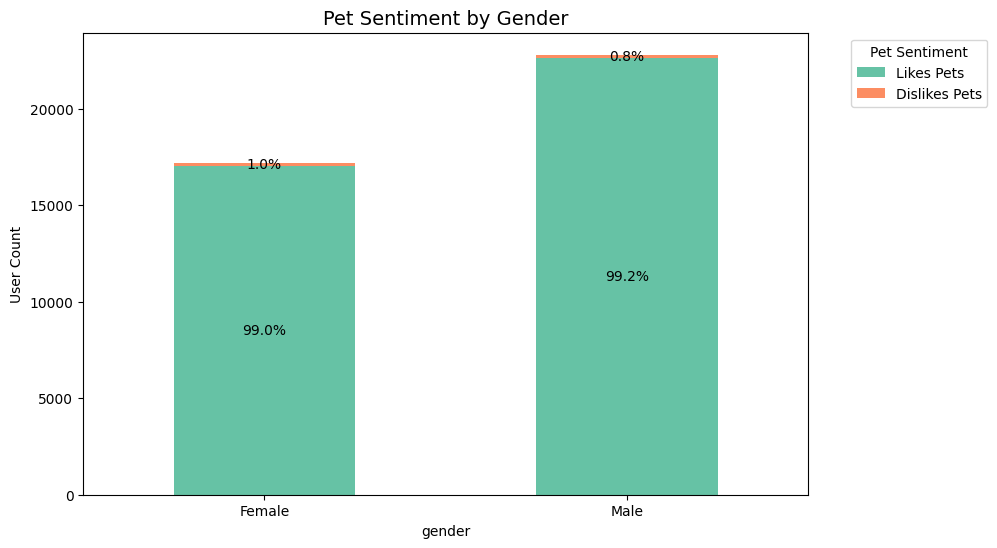

In [301]:
# 1. Prepare and Clean Data
sentiment_order = ['Likes Pets', 'Dislikes Pets']
gender_map = {'m': 'Male', 'f': 'Female'}
# Count data 
count_df = ( Bumble_df .groupby(['gender', 'pet_sentiment']) .size() .reset_index(name='count') )

pivot_df = count_df.pivot(index='gender', columns='pet_sentiment', values='count')[sentiment_order]
pivot_df.index = pivot_df.index.map(gender_map)

# 2. Plotting
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66c2a5', '#fc8d62'], rot=0)

# 3. Add Percentage Labels
for i, (gender, row) in enumerate(pivot_df.iterrows()):
    cumulative = 0
    total = row.sum()
    for val in row:
        if val > 0:
            ax.text(i, cumulative + val/2, f'{val/total:.1%}', ha='center', va='center')
        cumulative += val

# 4. Final Formatting & Legend Fix
plt.title('Pet Sentiment by Gender', fontsize=14)
plt.ylabel('User Count')
plt.legend(title='Pet Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

# This is the fix for the legend being cut off:
plt.subplots_adjust(right=0.85) 
plt.show()

**Analysis Approach**

- Analyzed pet sentiment distribution (likes vs dislikes) across gender
- Compared proportions to identify differences in preferences

**Insights**

- **Overwhelming Preference for Pets:** Both genders show an extremely high preference for pets (Female: 99.0%, Male: 99.2%).

- **Minimal Dislike Segment:** Very few users dislike pets (Female: 1.0%, Male: 0.8%).

- **Gender Difference:** Male users show a marginally higher preference for pets, but the difference is negligible.

- **Overall:** Pet preference is nearly universal across the platform, making it a non-differentiating factor between genders.

---

**Q2. How do pets preferences vary across gender and age_group? Are younger users more likely to report liking pets compared to older users?**

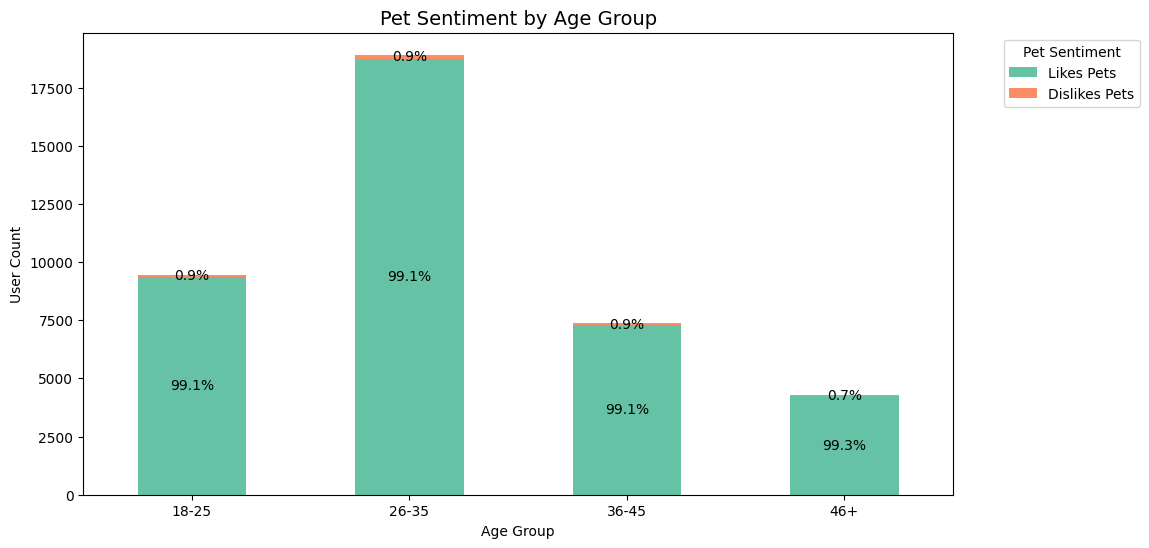

In [303]:
# Group and pivot
count_df_age = (
    Bumble_df[Bumble_df['pet_sentiment'] != 'Not Disclosed']
    .groupby(['age_group', 'pet_sentiment'], observed=False)
    .size()
    .reset_index(name='count')
)

pivot_df_age = count_df_age.pivot(index='age_group', columns='pet_sentiment', values='count')[sentiment_order]

# 2. Plotting
ax = pivot_df_age.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#66c2a5', '#fc8d62'], rot=0)

# 3. Add Percentage Labels
for i, (age_group, row) in enumerate(pivot_df_age.iterrows()):
    cumulative = 0
    total = row.sum()
    for val in row:
        if val > 0:
            # Use f-string with .1% for concise percentage formatting
            ax.text(i, cumulative + val/2, f'{val/total:.1%}', ha='center', va='center')
        cumulative += val

# 4. Final Formatting & Legend Fix
plt.title('Pet Sentiment by Age Group', fontsize=14)
plt.ylabel('User Count')
plt.xlabel('Age Group')
plt.legend(title='Pet Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust right margin to ensure legend stays inside the black outline
plt.subplots_adjust(right=0.85) 
plt.show()

**Analysis Approach**

- Analyzed pet sentiment distribution (likes vs dislikes) across age groups
- Compared proportions to identify variation in preferences by age


**Insights**

- **Universal Preference Across Ages:** All age groups show an extremely high preference for pets (~99%+), indicating strong consistency across demographics.

- **Lowest Dislike in Older Users:** The 46+ group has the lowest dislike rate (~0.7%), suggesting older users are slightly more favorable toward pets.

- **Consistent Younger & Mid Groups:** Age groups 18–25, 26–35, and 36–45 all show nearly identical dislike rates (~0.9%), indicating no meaningful variation.

- **Overall:** Pet preference remains stable across all age groups, making it a non-differentiating factor for age-based segmentation.

---
---


### **4. Signs and Personality**

Users’ self-reported zodiac signs (sign) can offer insights into personality preferences or trends. While not scientifically grounded, analyzing this data helps explore fun and engaging patterns.

**Q1. Create a pie chart showing the distribution of zodiac signs (sign) across the platform. Which signs are most and least represented? Is this the right chart? If not, replace with right chart.**


In [308]:
zodiac_signs = [
    'aries', 'taurus', 'gemini', 'cancer', 'leo', 'virgo',
    'libra', 'scorpio', 'sagittarius', 'capricorn', 'aquarius', 'pisces'
]
import re

pattern = r'^(' + '|'.join(zodiac_signs) + r')'

Bumble_df['zodiac_clean'] = (
    Bumble_df['sign']
    .str.lower()
    .str.extract(pattern, expand=False)
)


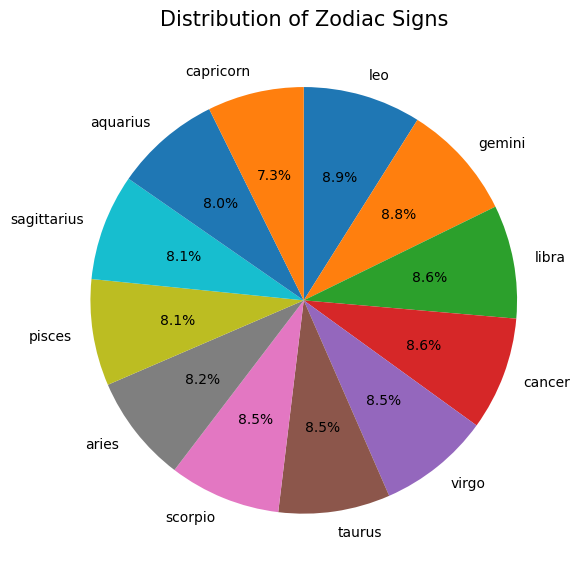

In [314]:
plt.figure(figsize=(6, 6))

plt.pie(
    sign_counts.values,
    labels=sign_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)

plt.title('Distribution of Zodiac Signs', fontsize=15)
plt.tight_layout()
plt.show()


**Chart Result Analysis The current pie chart has several issues:**

- **Too Many Categories:** A pie chart with 12 slices makes it difficult to distinguish between segments, especially when differences are small.

- **Minimal Variation:** All values lie within a narrow range (~7%–9%), making slice sizes visually almost identical and hard to compare.

- **Poor Comparability:** Human perception struggles to compare angles/areas accurately, especially when differences are subtle.

- **Cluttered Labels:** With many categories, labels become crowded and reduce readability.

- **No Clear Insight:** The chart does not highlight any meaningful pattern or standout category due to near-uniform distribution.

**This is not the correct chart fot the analysis**

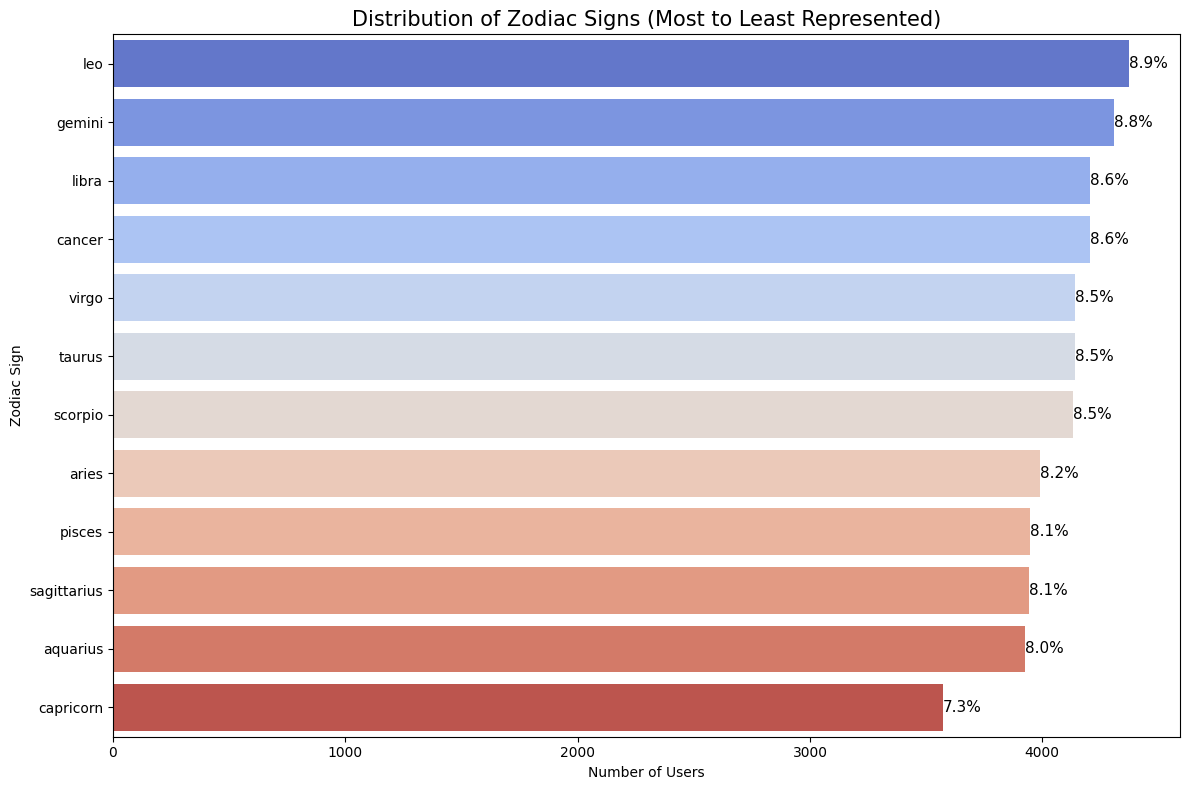

In [323]:
sign_counts = Bumble_df['zodiac_clean'].value_counts().sort_values(ascending=False)
percentages = sign_counts / sign_counts.sum() * 100
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=sign_counts.values,
    y=sign_counts.index,
    hue=sign_counts.index,
    palette='coolwarm',
    legend=False
)

# Add percentage labels
for i, (count, pct) in enumerate(zip(sign_counts.values, percentages.values)):
    ax.text(
        count,                  # x position (end of bar)
        i,                      # y position
        f'{pct:.1f}%',          # label text
        va='center',
        ha='left',
        fontsize=11
    )

plt.title('Distribution of Zodiac Signs (Most to Least Represented)', fontsize=15)
plt.xlabel('Number of Users')
plt.ylabel('Zodiac Sign')

plt.tight_layout()
plt.show()


**Analysis Approach**

- Extracted zodiac signs from the raw `sign` column using regex pattern matching
- Cleaned and standardized values into 12 zodiac categories
- Calculated frequency and percentage distribution of each sign
- Visualized the distribution in descending order

**Insights**

- **Even Distribution:** Zodiac signs are fairly evenly distributed, with most signs falling between ~8% to ~9% of users.

- **Top Signs:** Leo (8.9%) and Gemini (8.8%) are the most represented, though the difference is marginal.

- **Mid Range:** Signs like Libra, Cancer, Virgo, Taurus, and Scorpio cluster closely around ~8.5–8.6%.

- **Lower Representation:** Capricorn (~7.3%) is the least represented, but still not significantly lower than others.

- **Overall:** The distribution is nearly uniform across all zodiac signs, indicating no strong dominance of any particular sign in the user base.

---

**Q2. How does sign vary across gender and status? Are there noticeable patterns or imbalances?**

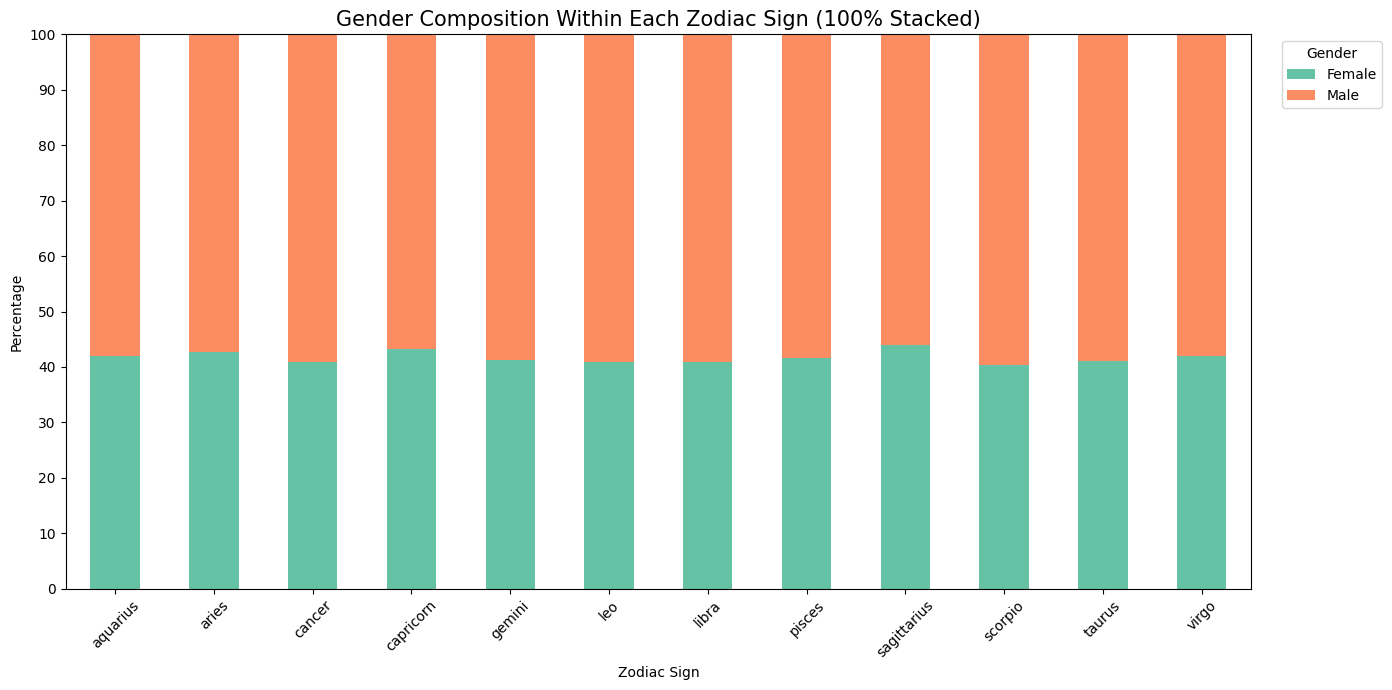

In [319]:
# Count zodiac × gender
sign_gender_counts = (
    Bumble_df
    .groupby(['zodiac_clean', 'gender'])
    .size()
    .reset_index(name='count')
)

# Map gender labels
gender_map = {'m': 'Male', 'f': 'Female'}
sign_gender_counts['gender'] = sign_gender_counts['gender'].map(gender_map)

# Convert to percentages per zodiac sign
sign_gender_pct = (
    sign_gender_counts
    .assign(
        percent=lambda x: x.groupby('zodiac_clean')['count']
        .transform(lambda s: s / s.sum() * 100)
    )
)
pivot_df = sign_gender_pct.pivot(
    index='zodiac_clean',
    columns='gender',
    values='percent'
)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))

pivot_df.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#66c2a5', '#fc8d62']  # optional
)

ax.set_title('Gender Composition Within Each Zodiac Sign (100% Stacked)', fontsize=15)
ax.set_xlabel('Zodiac Sign')
ax.set_ylabel('Percentage')

ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))

plt.xticks(rotation=45)
plt.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Analysis Approach**

- Calculated the gender composition within each zodiac sign
- Normalized values to percentages (100% stacked) for fair comparison
- Compared distributions to identify any gender skew across signs

**Insights**

- **Consistent Gender Split:** Across all zodiac signs, the gender distribution remains highly consistent, with males (~57–60%) and females (~40–43%).

- **No Strong Skew:** No zodiac sign shows a significant gender imbalance; variations are minimal across all categories.

- **Slight Male Majority:** Every sign has a slightly higher proportion of male users, but the difference is uniform rather than sign-specific.

- **Overall:** Zodiac sign does not meaningfully influence gender distribution, indicating no relationship between zodiac and gender composition.

---


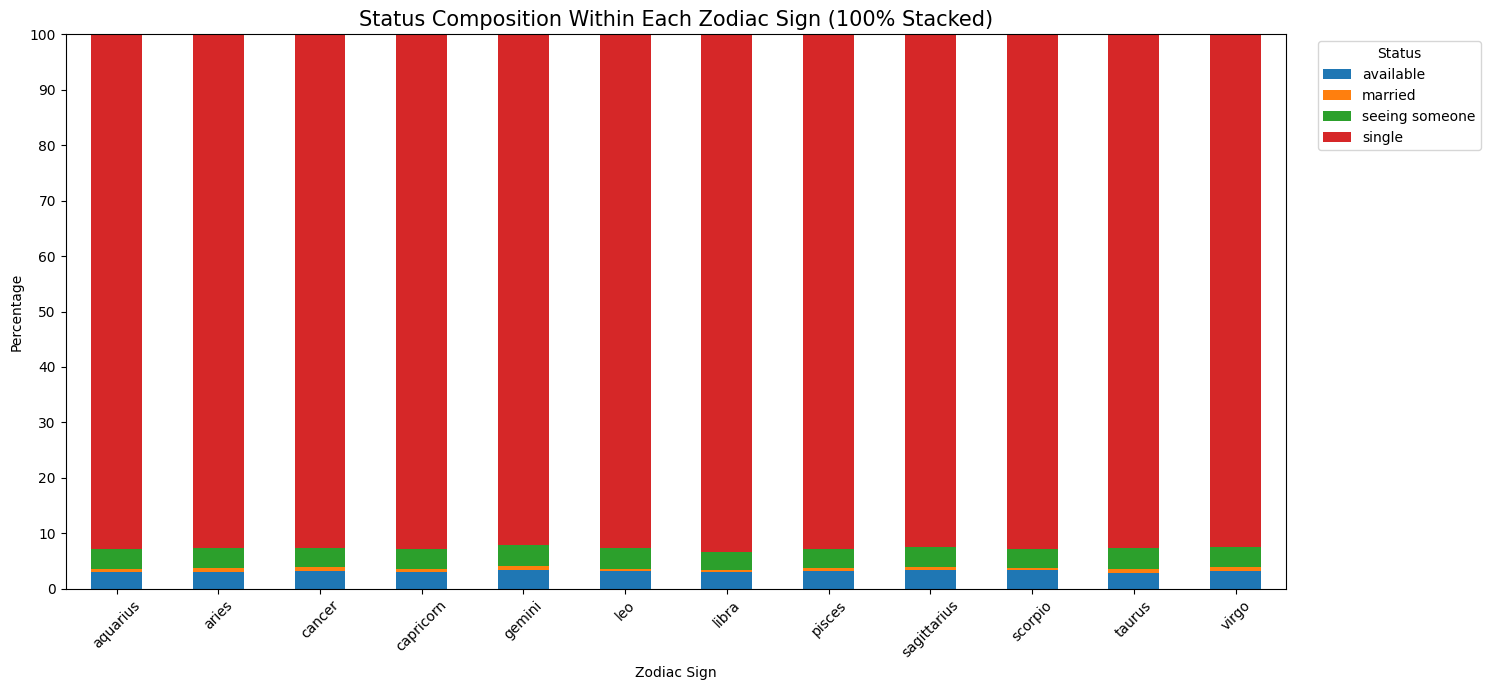

In [322]:
# Counts
sign_status_counts = (
    Bumble_df
    .groupby(['zodiac_clean', 'status'])
    .size()
    .reset_index(name='count')

)

# Convert to percentages within each zodiac sign
sign_status_pct = (
    sign_status_counts
    .assign(
        percent=lambda x: x.groupby('zodiac_clean')['count']
        .transform(lambda s: s / s.sum() * 100)
    )
)
pivot_df = sign_status_pct.pivot(
    index='zodiac_clean',
    columns='status',
    values='percent'
)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 7))

pivot_df.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

ax.set_title('Status Composition Within Each Zodiac Sign (100% Stacked)', fontsize=15)
ax.set_xlabel('Zodiac Sign')
ax.set_ylabel('Percentage')

ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))

plt.xticks(rotation=45)
plt.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



**Analysis Approach**

- Analyzed relationship status distribution within each zodiac sign
- Normalized values to percentages (100% stacked) for consistent comparison
- Compared patterns to identify any variation across signs

**Insights**

- **Single Dominance:** Across all zodiac signs, the vast majority of users are single (~92–94%), making it the dominant status in every category.

- **Minimal Variation:** Other statuses (available, seeing someone, married) each contribute only a small fraction (~1–5%) and show very little variation across signs.

- **Consistent Pattern:** The distribution of relationship status is nearly identical for all zodiac signs, with no sign showing a distinct behavioral pattern.

- **Overall:** Zodiac sign does not influence relationship status distribution, indicating no meaningful relationship between these variables.

---
---


## **Conclusion: Insights from Bumble User Analysis**

This multi-faceted analysis of the Bumble dataset reveals several key insights across age, income, pet preferences, and zodiac signs:

**Income & Age**:

- There is no strong correlation between age and income, as indicated by the flat regression trendline.
- The 26–35 age group reports the highest median income, followed by the 46+ group.
- Across gender and relationship status, men tend to report higher incomes than women, particularly among single and married users.

**Pets & Preferences**:

- The most popular pet preference is “likes dogs and likes cats”, highlighting strong overall pet friendliness.
- Younger users (18–25) favor liking both cats and dogs, while older users show more variation, including ownership and stronger preferences.
- Gender differences are minimal, with both men and women showing high affinity for pets.

**Signs & Personality**:

- The original pie chart was replaced by a more readable bar chart, better suited for visualizing zodiac sign distribution.
- Signs such as Leo, Scorpio, and Virgo are among the most represented.
- When segmented by gender and relationship status, no drastic imbalance is observed, though some variations exist across the top signs.

Overall, this analysis provides valuable demographic and behavioral segmentation clues. These insights could enhance personalization strategies, improve match recommendations, and support targeted marketing or user experience design within dating platforms like Bumble.

---
---
